# P4 — Final Integrated Analysis | Issue #22
**PDS301m — E-Commerce Analytics Pipeline**  
**Owner:** Mẫn · **Reviewer:** Huy · **Population:** UCI Online Retail, valid sales only.

**Research questions:** How do monthly/country revenue and product performance vary? Which customers have high/at-risk RFM value? Which orders are statistical outliers?

**Source contract:** Revenue/EDA uses `src/eda.py`; RFM uses `src/feature_engineering.py`; anomaly IQR uses `src/anomaly_detector.py`; reconciliation uses `src/reconcile.py`; cleaning fallback uses `src/data_processor.py`. Books to Scrape is a separate scraping practice artifact, **never joined** with transactions.

**Reproduction:** Open in `notebooks/`, restart kernel → Run All. Run at repository root after `pip install -r requirements.txt`. CSV inputs live in `data/processed/`, scraping evidence in `data/raw/`. When cleaned data is missing, the raw Excel fallback reruns the existing processor. Existing `customer_segments.csv` is verified against recomputed RFM; a missing file is regenerated from the same `src/` function. No live network dependency.

## 1. Setup and input locations

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Works from notebooks/, repository root, or an external current directory when the
# kernel is launched with this notebook as working directory.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src' / 'eda.py').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Repository root not found. Launch Jupyter from the repository or notebooks/.')
sys.path.insert(0, str(ROOT / 'src'))
from eda import total_revenue, revenue_by_month, revenue_by_country, top_products, order_values
from feature_engineering import calculate_rfm
from anomaly_detector import OrderAnomalyDetector
from scraper import validate_data
from reconcile import revenue_totals, rfm_monetary_total, revenue_by_segment

PROC = ROOT / 'data' / 'processed'; RAW = ROOT / 'data' / 'raw'
CHARTS = ROOT / 'charts'; CHARTS.mkdir(parents=True, exist_ok=True)
PROC.mkdir(parents=True, exist_ok=True)
print('Repository:', ROOT)

Repository: /mnt/data/pds301m-ecommerce-analytics-develop


## 2. Load / reproduce cleaned sales and verify assumptions

In [2]:
clean_path = PROC / 'cleaned_retail.csv'
if not clean_path.exists():
    from data_processor import RetailDataProcessor
    raw_file = RAW / 'online_retail.xlsx'
    if not raw_file.exists():
        raise FileNotFoundError(f'Missing {clean_path} and raw fallback {raw_file}')
    processor = RetailDataProcessor(raw_file)
    processor.load_and_explore()
    processor.clean_data(deduplicate=True, fill_guest=True)
    processor.engineer_features()
    processor.export_data(clean_path, PROC / 'cancelled_retail.csv')

df = pd.read_csv(clean_path, dtype={'InvoiceNo': 'string', 'StockCode': 'string', 'CustomerID': 'string'})
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='raise')
required = {'InvoiceNo','StockCode','Quantity','UnitPrice','CustomerID','Country','Revenue','YearMonth','InvoiceDate'}
assert required <= set(df.columns), f'Missing columns: {required - set(df.columns)}'
assert not df['InvoiceNo'].str.startswith('C', na=False).any()
assert (df['Quantity'] > 0).all() and (df['UnitPrice'] > 0).all()
assert not df.duplicated().any()
assert np.allclose(df['Revenue'].to_numpy(), (df['Quantity']*df['UnitPrice']).to_numpy(), atol=1e-7)
assert (df['InvoiceDate'].dt.strftime('%Y-%m') == df['YearMonth']).all()
print('Cleaned rows:', format(len(df),','), '| Dates:', df['InvoiceDate'].min(), 'to', df['InvoiceDate'].max())
print('Revenue:', f"£{total_revenue(df):,.2f}", '| Guest rows:', int(df['CustomerID'].eq('Guest').sum()))
display(df.head(3))

Cleaned rows: 524,878 | Dates: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Revenue: £10,642,110.80 | Guest rows: 132186


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12


**Cleaning assumptions:** `InvoiceNo` beginning with `C`, nonpositive quantity/price, and exact duplicates are removed upstream. Missing `CustomerID` is retained as `Guest` for revenue, excluded from RFM. Do not remove service codes from aggregate revenue; they are excluded from product rankings via `src/eda.py`. Monthly observations at the dataset boundaries are partial months.

## 3. Web Scraping Practice — independent evidence (#4)

In [3]:
books_path = next((p for p in (RAW/'scraped_books.csv', PROC/'scraped_books.csv') if p.exists()), None)
if books_path is None:
    raise FileNotFoundError('Missing scraped_books.csv; supply Issue #4 artifact (offline review mode).')
books = pd.read_csv(books_path, encoding='utf-8-sig')
assert {'title','price','rating'} <= set(books.columns)
scrape_audit = validate_data(books)
print('Books scraping validation:', scrape_audit)
assert scrape_audit['total_issues'] == 0, 'Scraping validation failed'
display(books.head(5))
print('Scraped titles:', len(books), '| Source pagination: Books to Scrape (50 pages × up to 20 titles).')

Books scraping validation: {'total': 1000, 'total_issues': np.int64(0), 'invalid_title': np.int64(0), 'invalid_price': np.int64(0), 'invalid_rating': np.int64(0), 'duplicates': np.int64(0)}


,title,price,rating
0,A Light in the Attic,51.77,3
1,Tipping the Velvet,53.74,1
2,Soumission,50.10,1
3,Sharp Objects,47.82,4
4,Sapiens: A Brief History of Humankind,54.23,5


Scraped titles: 1000 | Source pagination: Books to Scrape (50 pages × up to 20 titles).


**Evidence and limitation:** `src/scraper.py` handles HTML parsing, rating conversion, page traversal and validation. The saved CSV establishes the extract; the CSV alone cannot independently prove every live HTTP page was fetched, so the pagination implementation is cited as code evidence. Do not aggregate scraping prices with UCI sales.

## 4. Revenue trend and country mix (#7)

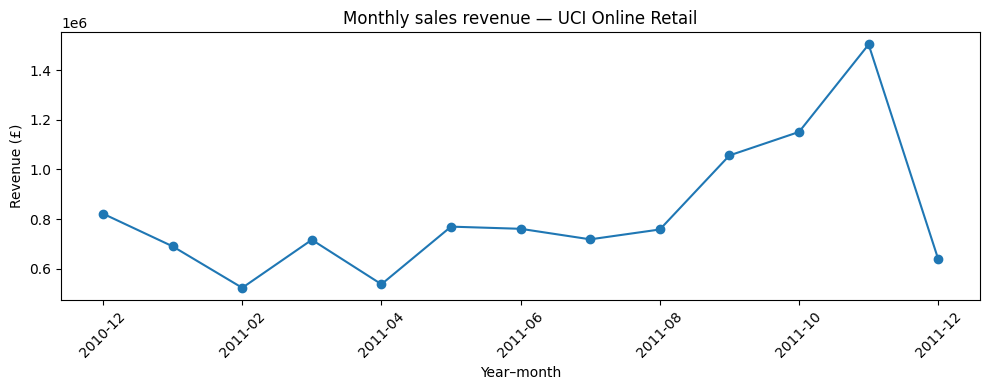

,Revenue (£)
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


Peak month: 2011-11 | UK revenue share: 84.6%


In [4]:
monthly = revenue_by_month(df)
country = revenue_by_country(df)
fig, ax = plt.subplots(figsize=(10,4))
monthly.plot(ax=ax, marker='o')
ax.set(title='Monthly sales revenue — UCI Online Retail', xlabel='Year–month', ylabel='Revenue (£)')
ax.tick_params(axis='x', rotation=45)
fig.tight_layout(); fig.savefig(CHARTS/'final_monthly_revenue.png', dpi=150); plt.show()
display(country.head(10).rename('Revenue (£)').to_frame())
print('Peak month:', monthly.idxmax(), '| UK revenue share:', f"{country.get('United Kingdom', 0)/country.sum():.1%}")

## 5. Products — top revenue and top volume (#7)

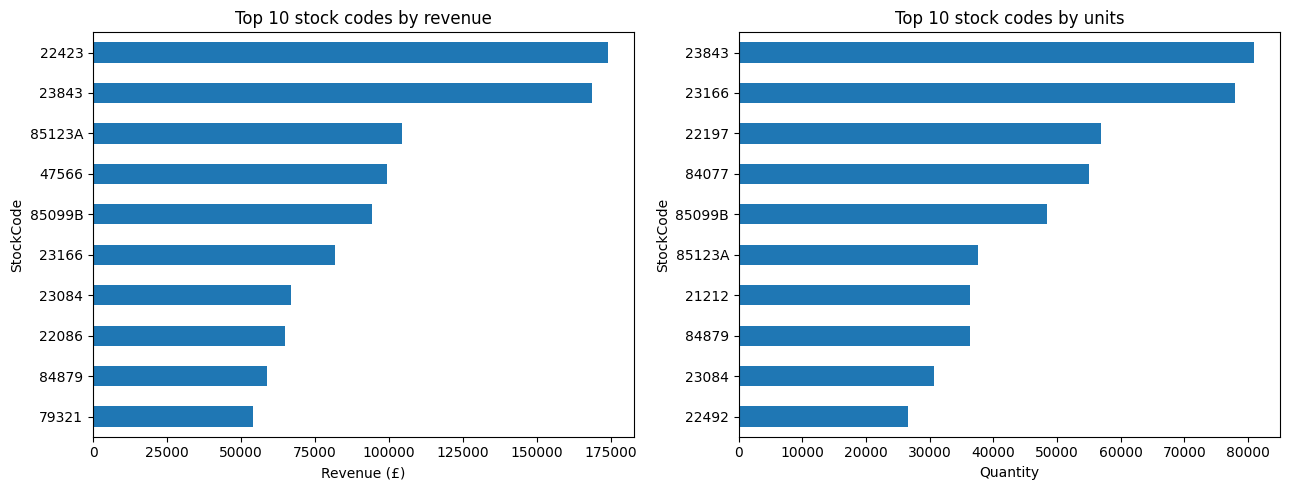

Revenue leader: 22423 | Quantity leader: 23843


In [5]:
tops_revenue = top_products(df, metric='Revenue', n=10)
tops_quantity = top_products(df, metric='Quantity', n=10)
fig, axes = plt.subplots(1,2,figsize=(13,5))
tops_revenue.sort_values().plot.barh(ax=axes[0], title='Top 10 stock codes by revenue', xlabel='Revenue (£)')
tops_quantity.sort_values().plot.barh(ax=axes[1], title='Top 10 stock codes by units', xlabel='Quantity')
fig.tight_layout(); fig.savefig(CHARTS/'final_top_products.png', dpi=150); plt.show()
print('Revenue leader:', tops_revenue.index[0], '| Quantity leader:', tops_quantity.index[0])

## 6. Customer RFM segmentation (#8/#15)

Saved customer_segments.csv matches src/feature_engineering.py.


,Customers,Monetary
Segment,,
Champions,911,5676143.380
At Risk,938,1161835.102
Loyal Customers,381,823495.761
Potential Loyalists,484,583120.230
Others,835,465436.790
Hibernating,789,177177.631


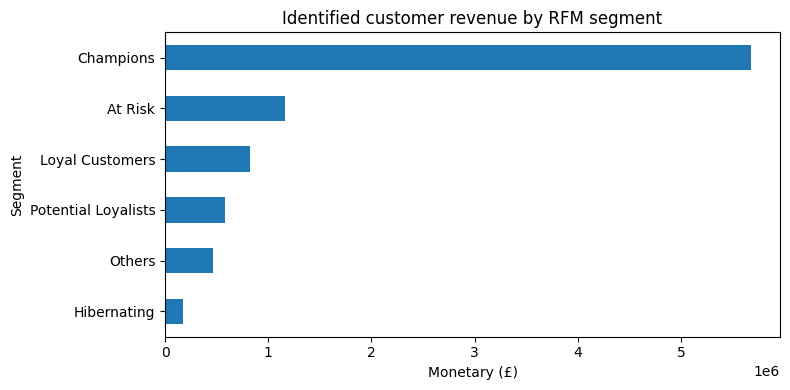

In [6]:
segment_path = PROC/'customer_segments.csv'
# Recompute from primary reusable RFM source even when a supplied CSV exists.
rfm = calculate_rfm(df)
rfm['CustomerID'] = rfm['CustomerID'].astype('string')
if segment_path.exists():
    supplied = pd.read_csv(segment_path, dtype={'CustomerID':'string'})
    assert supplied['CustomerID'].is_unique and len(supplied) == len(rfm)
    compare = supplied.set_index('CustomerID').sort_index().join(
        rfm.set_index('CustomerID')[['Frequency','Monetary','Segment']].sort_index(),
        lsuffix='_saved', rsuffix='_recomputed', how='outer', validate='one_to_one'
    )
    assert (compare['Frequency_saved'] == compare['Frequency_recomputed']).all()
    assert np.allclose(compare['Monetary_saved'], compare['Monetary_recomputed'], atol=1e-6)
    assert (compare['Segment_saved'] == compare['Segment_recomputed']).all()
    print('Saved customer_segments.csv matches src/feature_engineering.py.')
else:
    rfm.to_csv(segment_path,index=False)
    print('Regenerated customer_segments.csv using src/feature_engineering.py.')
segments = rfm
segment_view = segments.groupby('Segment').agg(Customers=('CustomerID','nunique'), Monetary=('Monetary','sum')).sort_values('Monetary',ascending=False)
display(segment_view)
ax = segment_view['Monetary'].sort_values().plot.barh(figsize=(8,4), title='Identified customer revenue by RFM segment')
ax.set_xlabel('Monetary (£)'); plt.tight_layout(); plt.savefig(CHARTS/'final_rfm_segment_revenue.png', dpi=150); plt.show()

**RFM definitions:** Recency in days relative to day after last valid purchase; Frequency counts distinct successful invoice numbers; Monetary sums identified customers' valid revenue. Percentile-based scoring and mutually exclusive segment rules are implemented only in `src/feature_engineering.py`. `Guest` is not a segment.

## 7. Order-level anomalies (#16)


=== 2. PHÁT HIỆN NGOẠI LỆ GIÁ TRỊ CAO (UPPER-TAIL IQR) ===
- Doanh thu (Revenue): Q1=£151.70, Q3=£493.46, IQR=£341.77 -> Ngưỡng Q3 + 1.5*IQR = £1,006.11
- Số lượng (Quantity): Q1=69.0, Q3=296.0, IQR=227.0 -> Ngưỡng Q3 + 1.5*IQR = 636.5
- Số đơn ngoại lệ theo Revenue:     1,811
- Số đơn ngoại lệ theo Quantity:    1,445
- Số đơn ngoại lệ Combined:         2,185
Invoices: 19960 | Any IQR anomaly: 2185 | Revenue anomaly: 1811 | Quantity anomaly: 1445


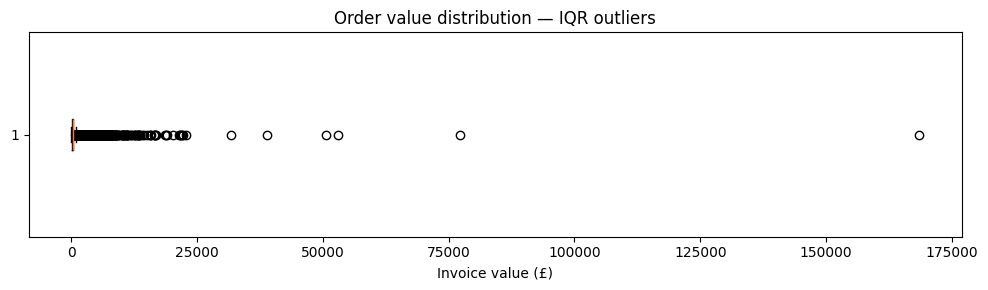

,InvoiceNo,Revenue,TotalQuantity,LineCount,IsRevenueAnomaly,IsQuantityAnomaly,IsAnomaly
19923,581483,168469.60,80995,1,True,True,True
2116,541431,77183.60,74215,1,True,True,True
16923,574941,52940.94,14149,101,True,True,True
17579,576365,50653.91,13956,99,True,True,True
8693,556444,38970.00,60,1,True,False,True


In [7]:
detector = OrderAnomalyDetector(df_valid=df)
orders = detector.aggregate_orders()
flagged = detector.detect_iqr_anomalies()
print('Invoices:', len(flagged), '| Any IQR anomaly:', int(flagged['IsAnomaly'].sum()),
      '| Revenue anomaly:', int(flagged['IsRevenueAnomaly'].sum()),
      '| Quantity anomaly:', int(flagged['IsQuantityAnomaly'].sum()))
fig, ax = plt.subplots(figsize=(10,3))
ax.boxplot(order_values(df).to_numpy(), vert=False)
ax.set(xlabel='Invoice value (£)', title='Order value distribution — IQR outliers')
fig.tight_layout(); fig.savefig(CHARTS/'final_order_value_boxplot.png',dpi=150); plt.show()
display(flagged.nlargest(5,'Revenue'))

**Interpretation:** `src/anomaly_detector.py` applies Q3 + 1.5×IQR on order revenue and total quantity. A statistical outlier may be a legitimate wholesale order; it is **not** evidence of fraud. Cancelled-order counts require `cancelled_retail.csv`; their absence is explicitly marked in the reconciliation section.

## 8. KPI reconciliation against Issue #18

In [8]:
total, identified, guest = revenue_totals(df)
rfm_total = rfm_monetary_total(segments)
# Avoid the original cross-platform Windows-path concatenation; reuse reconcile function with Path.
joined = revenue_by_segment(df, segments, PROC/'revenue_by_segment.csv')
by_seg = joined.groupby('Segment')['Revenue'].sum()
expected = {'Champions':5676143.38, 'At Risk':1161835.10, 'Loyal Customers':823495.76,
            'Potential Loyalists':583120.23, 'Others':465436.79, 'Hibernating':177177.63}
checks = {
    'Valid sale lines': (len(df), 524878),
    'Total revenue (£)': (round(total,2), 10642110.80),
    'Non-Guest revenue (£)': (round(identified,2), 8887208.89),
    'Guest revenue (£)': (round(guest,2), 1754901.91),
    'RFM Monetary (£)': (round(rfm_total,2), 8887208.89),
    'Number of RFM segments': (len(by_seg), 6),
    'Rows invalid after cleaning': (int(((df.Quantity<=0)|(df.UnitPrice<=0)).sum()), 0),
    'Exact duplicate rows': (int(df.duplicated().sum()), 0),
}
for name, val in expected.items():
    checks[f'Segment: {name} (£)']=(round(float(by_seg[name]),2),val)
reconciliation = pd.DataFrame([{'Metric':k,'Actual':v[0],'Issue #18 expected':v[1],
                                'Matches': bool(np.isclose(v[0],v[1],rtol=0,atol=.011))} for k,v in checks.items()])
display(reconciliation)
assert reconciliation['Matches'].all(), 'KPI inconsistency with reports/kpi_reconciliation.md'
assert np.isclose(total, identified+guest, atol=.01)
assert np.isclose(identified, by_seg.sum(), atol=.01)
cancel_path=PROC/'cancelled_retail.csv'
if cancel_path.exists():
    cancelled=pd.read_csv(cancel_path,dtype={'InvoiceNo':'string'})
    cancelled_count=cancelled['InvoiceNo'].nunique()
    print('Cancelled invoices:',cancelled_count)
    assert cancelled_count == 9251, 'Cancellation audit differs from Issue #18'
else:
    print('Cancellation audit: SKIPPED (cancelled_retail.csv not supplied; Issue #18 reports 9,251).')
print('Issue #18 reconciliation: all available KPI checks passed.')

,Metric,Actual,Issue #18 expected,Matches
0,Valid sale lines,524878.00,524878.00,True
1,Total revenue (£),10642110.80,10642110.80,True
2,Non-Guest revenue (£),8887208.89,8887208.89,True
3,Guest revenue (£),1754901.91,1754901.91,True
4,RFM Monetary (£),8887208.89,8887208.89,True
5,Number of RFM segments,6.00,6.00,True
6,Rows invalid after cleaning,0.00,0.00,True
7,Exact duplicate rows,0.00,0.00,True
8,Segment: Champions (£),5676143.38,5676143.38,True
9,Segment: At Risk (£),1161835.10,1161835.10,True


Cancellation audit: SKIPPED (cancelled_retail.csv not supplied; Issue #18 reports 9,251).
Issue #18 reconciliation: all available KPI checks passed.


## 9. Integrated business findings and limitations

**Revenue:** Country concentration (UK dominated) and the November 2011 peak are relevant for forecasting, but December boundary months are incomplete.  
**Products:** Stock codes leading by quantity are not identical to those leading by revenue; compare both metrics before assortment decisions. Service/fee codes are excluded only from product rankings.  
**Customers:** Champions account for the largest identified-customer revenue share, while At Risk is the next major retention opportunity. Interpret RFM as descriptive segmentation rather than causal proof of campaign response.  
**Anomalies:** Large-order and high-quantity flags should be examined against wholesale purchases and invoice context rather than automatically removed.  
**Source separation:** Books to Scrape is coursework evidence, not a transaction-level enrichment dataset.

**Limitations:** One UK-based merchant, a little over one year, partial boundary months, guest revenue not attributable to customers, descriptive observational findings, and IQR sensitivity to heavy-tailed wholesale transactions. KPI #18 cancellation audit is only independently rechecked when the optional cancellation CSV is available.

**Report handoff #19:** Reuse displayed groupby tables, the reconciliation table and `charts/final_*.png`. Notebook is an integration artifact, not a fork of core logic.

## 10. Output and Run All completion

In [9]:
required_charts = ['final_monthly_revenue.png','final_top_products.png','final_order_value_boxplot.png','final_rfm_segment_revenue.png']
assert all((CHARTS/p).is_file() for p in required_charts)
assert (PROC/'revenue_by_segment.csv').is_file()
print('PASS — 4 final chart files, RFM output, segment reconciliation and all available KPI checks.')
print('Charts:', CHARTS)
print('Data:', PROC)

PASS — 4 final chart files, RFM output, segment reconciliation and all available KPI checks.
Charts: /mnt/data/pds301m-ecommerce-analytics-develop/charts
Data: /mnt/data/pds301m-ecommerce-analytics-develop/data/processed
